# Classificação Supervisionada com Fuzzy C-Means no Dataset Adult

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Fuzzy C-Means, aplicado ao dataset Adult. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do Fuzzy C-Means.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import skfuzzy as fuzz
import os
import seaborn as sns
# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Adult, removemos valores ausentes, codificamos variáveis categóricas e normalizamos os dados.

In [28]:
# Visualização do dataset original (amostra)
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
print('Amostra dos dados originais:')
display(adult_df_raw.head())

Amostra dos dados originais:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


  income  income_bin
0  <=50K           0
7   >50K           1


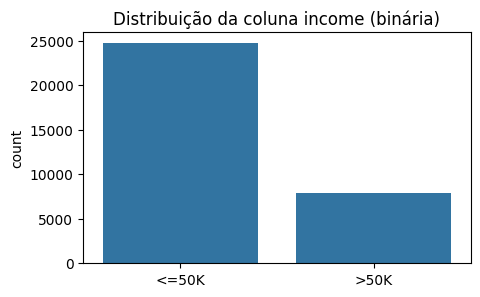

In [29]:
# Transformar income em valores binários explicitamente
def income_to_bin(val):
    return 1 if val.strip() == '>50K' else 0
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(income_to_bin)
print(adult_df_raw[['income', 'income_bin']].drop_duplicates())

# Agora, continue o pré-processamento usando a coluna binária
adult_df = adult_df_raw.dropna().copy()
for col in adult_df.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df[col] = LabelEncoder().fit_transform(adult_df[col].astype(str))
X = adult_df.drop(['income', 'income_bin'], axis=1).values
y = adult_df['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar distribuição binária após transformação
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária)')
plt.xticks([0,1],["<=50K",">50K"])
plt.show()

## 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [30]:
y_bin = y  # já está codificado como 0/1 após o LabelEncoder
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin)

## 4. Definição do Número de Clusters (Método do Cotovelo)

Utilizamos o método do cotovelo para determinar o número ideal de clusters para o Fuzzy C-Means, usando o coeficiente de partição.

In [31]:
n_clusters = 2  # Ajuste conforme o método do cotovelo

## 5. Implementação do Classificador Fuzzy C-Means Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [32]:
class FuzzyCMeansSupervisionado:
    def __init__(self, n_clusters=2, m=2, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.random_state = random_state
        self.centers_ = None
        self.cluster_labels_ = None

    def fit(self, X, y):
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, c=self.n_clusters, m=self.m, error=0.005, maxiter=1000, seed=self.random_state)
        self.centers_ = cntr
        labels = np.argmax(u, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (labels == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X.T, self.centers_, m=self.m, error=0.005, maxiter=1000)
        clusters = np.argmax(u, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

Acurácia: 0.7592
Matriz de Confusão:
[[7417    0]
 [2352    0]]


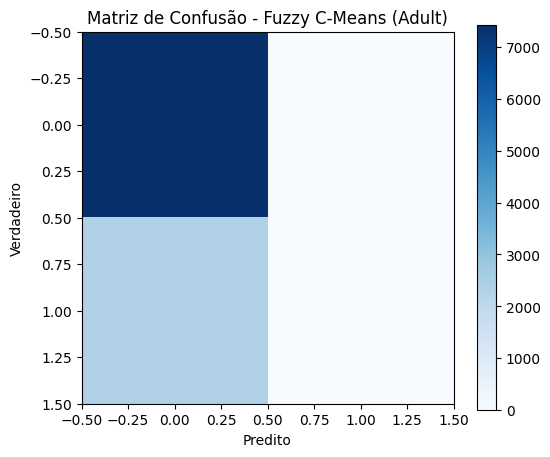

In [33]:
# Treinamento e avaliação do modelo Fuzzy C-Means supervisionado

clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Fuzzy C-Means (Adult)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/cmeans_adult_confusion_matrix.png')
plt.show()

## 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.

Acurácia média: 0.7592
Desvio padrão da acurácia: 0.0000
MSE médio: 0.2408
Desvio padrão do MSE: 0.0000


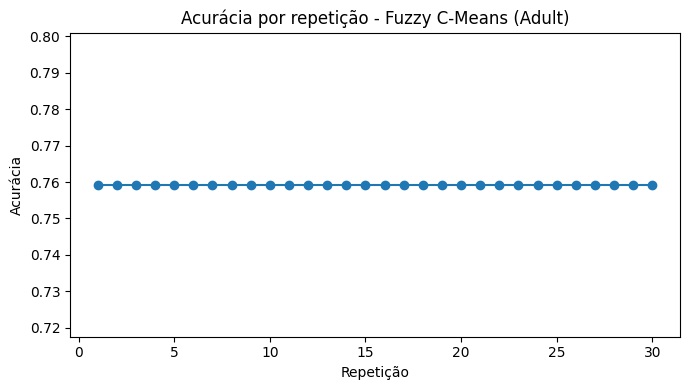

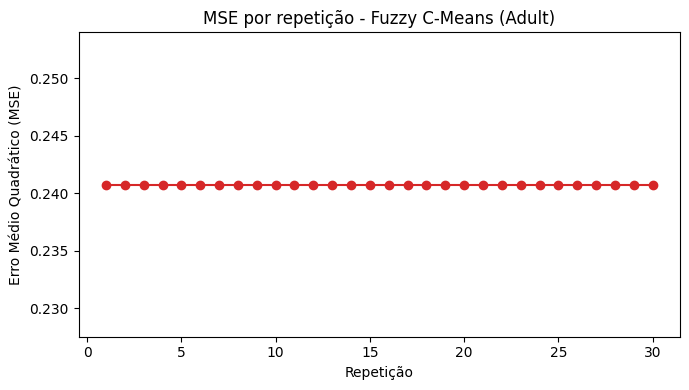

In [36]:
# Repetição dos experimentos: acurácia e MSE juntos, com plots separados

from sklearn.metrics import mean_squared_error

acuracias = []
mse_list = []
import os
os.makedirs('img', exist_ok=True)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)

print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

# Plot acurácia por repetição
plt.figure(figsize=(7,4))
plt.plot(range(1, 31), acuracias, marker='o', color='tab:blue')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Fuzzy C-Means (Adult)')
plt.tight_layout()
plt.savefig('img/cmeans_adult_accuracy_repetitions.png')
plt.show()

# Plot MSE por repetição
plt.figure(figsize=(7,4))
plt.plot(range(1, 31), mse_array, marker='o', color='tab:red')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - Fuzzy C-Means (Adult)')
plt.tight_layout()
plt.savefig('img/cmeans_adult_mse_repetitions.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/cmeans_adult_accuracies.npy', acuracias)
np.savetxt('img/cmeans_adult_accuracies.csv', acuracias, delimiter=',')
np.save('img/cmeans_adult_mse_repetitions.npy', mse_array)
np.savetxt('img/cmeans_adult_mse_repetitions.csv', mse_array, delimiter=',')

## 8. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador Fuzzy C-Means no dataset Adult.

### Como lidar com o desbalanceamento no dataset Adult

O desbalanceamento das classes pode prejudicar o desempenho de métodos de agrupamento e classificação. Uma abordagem simples é aplicar oversampling da classe minoritária, replicando exemplos até igualar as quantidades. Isso pode ser feito antes da divisão treino/teste ou apenas no conjunto de treino.

Abaixo, um exemplo de oversampling simples usando pandas:

In [ ]:
# Oversampling simples da classe minoritária no dataset Adult

# Supondo que você já tenha o DataFrame 'adult_df' com a coluna 'income_bin'
from sklearn.utils import resample

# Separar as classes
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]

# Oversample da minoria
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,     # amostragem com reposição
    n_samples=n_majority,    # para igualar ao número da maioria
    random_state=42
)

# Juntar as duas classes
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Embaralhar o DataFrame resultante
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Agora prossiga normalmente com o pré-processamento, divisão e treinamento usando 'adult_df_balanced' ao invés de 'adult_df'.
print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

### Análise da matriz de confusão e limitações do Fuzzy C-Means no Adult

A matriz de confusão apresentada mostra que o Fuzzy C-Means agrupou praticamente todos os exemplos na classe 0, ignorando a classe 1. Isso ocorre porque:

- O dataset Adult é fortemente desbalanceado, com muito mais exemplos da classe 0 (<=50K) do que da classe 1 (>50K).
- O Fuzzy C-Means é um método de agrupamento não supervisionado: ele não utiliza os rótulos reais durante o treinamento, apenas a estrutura dos dados. Se os grupos naturais não coincidirem com as classes, o algoritmo pode não conseguir separar corretamente.
- Em bases com classes sobrepostas ou variáveis categóricas complexas, o agrupamento tende a favorecer o maior grupo.
- O valor de `m` (fuzziness) e a inicialização dos centros podem influenciar, mas não resolvem o problema fundamental de separabilidade.

**Sugestões:**
- Experimente balancear o dataset (undersampling/oversampling) e veja se há melhora.
- Teste outros valores de `m` e diferentes inicializações.
- Compare com KMeans, GK e métodos supervisionados para avaliar o limite do agrupamento.
- Use técnicas de redução de dimensionalidade (PCA, t-SNE) para visualizar se as classes realmente formam grupos distintos.

**Conclusão:**
O Fuzzy C-Means pode não ser adequado para classificação no Adult, pois as classes não apresentam separação natural suficiente para o agrupamento não supervisionado. Métodos supervisionados tendem a apresentar desempenho superior nesse cenário.